# Повний зріз: AI-видимість українських брендів у відповідях LLM

5 галузевих груп (банки, e-commerce, аптеки, пошта і логістика, доставка їжі) × 80 запитів × 2 мови × 5 конфігурацій моделей × 5 повторів = 4 000 викликів.

Дизайн — `sample-design.md` і `design.py`, логіка — `audit.py`, тести — `test_audit.py`. Методику перевірено пілотом `pilot_banks.ipynb`.

Клітинки, що витрачають гроші, вимкнені прапорцями `RUN_*`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import find_dotenv, load_dotenv

import audit
from design import INDUSTRIES

load_dotenv(find_dotenv(usecwd=True))

RESPONSES_PATH = Path("data/full_responses.jsonl")
JUDGEMENTS_PATH = Path("data/full_judgements.jsonl")
PILOT_RESPONSES_PATH = Path("data/pilot_responses.jsonl")
PILOT_JUDGEMENTS_PATH = Path("data/pilot_judgements.jsonl")

REPEATS = 5
LANGS = ["uk", "en"]

MODEL_CONFIGS = [
    {"model": "openai/gpt-5.6-sol", "web_search": False},
    {"model": "anthropic/claude-sonnet-5", "web_search": False},
    {"model": "google/gemini-3.8-flash", "web_search": False},
    {"model": "deepseek/deepseek-v4-pro-0813", "web_search": False},
    {"model": "perplexity/sonar-pro", "web_search": True, "native_search": True},
]
JUDGE_MODEL = "openai/gpt-5.6-luna"

REUSE_PILOT = True
RUN_COLLECTION = False
RUN_JUDGE = False

## 1. Завдання та оцінка вартості

`REUSE_PILOT = True` переносить у файл повного зрізу україномовні банківські відповіді з пілота (зібрані 2026-09-18), щоб не платити за них удруге. Якщо важливіше єдине часове вікно збору — постав `False`.

In [2]:
tasks = [
    task
    for industry in INDUSTRIES
    for lang in LANGS
    for task in audit.build_tasks(MODEL_CONFIGS, audit.build_industry_queries(industry, lang), REPEATS, lang=lang)
]
wanted = {audit.task_key(t) for t in tasks}

if REUSE_PILOT:
    print("Перенесено з пілота відповідей:", audit.seed_from(PILOT_RESPONSES_PATH, RESPONSES_PATH, wanted))
    print("Перенесено з пілота оцінок:", audit.seed_from(PILOT_JUDGEMENTS_PATH, JUDGEMENTS_PATH, wanted, key_of=lambda j: tuple(j["key"])))

done = {audit.task_key(r) for r in audit.load_jsonl(RESPONSES_PATH)}
pending = [t for t in tasks if audit.task_key(t) not in done]

prices = audit.fetch_catalog_prices()
missing = sorted(({t["model"] for t in tasks} | {JUDGE_MODEL}) - set(prices))
assert not missing, f"Немає в каталозі OpenRouter: {missing}"

estimate = audit.estimate_cost(pending, prices) if pending else None
print(f"Завдань: {len(tasks)}, уже зібрано: {len(tasks) - len(pending)}, лишилося: {len(pending)}")
if pending:
    print(f"Оцінка збору: ${estimate['cost_usd'].sum():.2f}")
estimate

Перенесено з пілота відповідей: 0
Перенесено з пілота оцінок: 0
Завдань: 4000, уже зібрано: 4000, лишилося: 0


## 2. Збір відповідей і оцінювання суддею

Обидва кроки можна переривати й запускати знову. Обрізані за лімітом токенів відповіді автоматично відкладаються і збираються наново.

In [3]:
if RUN_COLLECTION:
    moved = audit.set_aside_truncated(RESPONSES_PATH, JUDGEMENTS_PATH)
    print(f"Обрізаних відповідей відкладено для повторного збору: {moved}")
    failed = audit.run_collection(tasks, RESPONSES_PATH, workers=6)
    for task, error in failed[:10]:
        print(audit.task_key(task), error)

In [4]:
if RUN_JUDGE:
    to_judge = [r for r in audit.load_jsonl(RESPONSES_PATH) if audit.task_key(r) in wanted]
    failed = audit.run_judging(to_judge, JUDGEMENTS_PATH, JUDGE_MODEL)
    print(failed[:10])

## 3. Дані та контроль якості

In [5]:
records = [r for r in audit.load_jsonl(RESPONSES_PATH) if audit.task_key(r) in wanted]
judgements = audit.load_jsonl(JUDGEMENTS_PATH)
responses = audit.responses_frame(records)

print(f"Відповідей: {len(responses)} із {len(tasks)}, фактична вартість: ${responses['cost_usd'].sum():.2f}")
print(f"Зріз: {responses['timestamp'].min()} — {responses['timestamp'].max()}")
print(f"Обрізаних: {responses['truncated'].sum()}, порожніх: {(responses['response_text'] == '').sum()}, оцінок судді: {len(judgements)}")

print("\nМова відповіді залежно від мови запиту:")
print(pd.crosstab([responses["model_label"], responses["lang"]], responses["response_lang"]))

Відповідей: 4000 із 4000, фактична вартість: $29.02
Зріз: 2026-09-18T15:39:00.628223+00:00 — 2026-09-21T22:16:05.761427+00:00
Обрізаних: 0, порожніх: 0, оцінок судді: 4000

Мова відповіді залежно від мови запиту:
response_lang               en  ru   uk
model_label          lang              
claude-sonnet-5      en    248   0  152
                     uk      0   0  400
deepseek-v4-pro-0813 en    263   3  134
                     uk      0  10  390
gemini-3.8-flash     en    102   1  297
                     uk      0   0  400
gpt-5.6-sol          en    289   0  111
                     uk      0   1  399
sonar-pro +web       en    368   1   31
                     uk      0   0  400


## 4. Звіт по галузі

Для кожної галузі: згадуваність за моделями (окремо для кожної мови запиту), порівняння мов, інтенти, стабільність, тональність, бренди поза списком і джерела цитування.

In [6]:
def industry_frames(industry):
    spec = INDUSTRIES[industry]
    recs = [r for r in records if r["industry"] == industry]
    resp = responses[responses["industry"] == industry]
    ment = audit.mentions_frame(recs, spec["brands"])
    sent = audit.sentiment_frame(recs, judgements, spec["brands"])
    cites = audit.citations_frame(recs, spec["domains"])
    return spec, resp, ment, sent, cites


def mention_heatmaps(spec, resp, ment):
    fig, axes = plt.subplots(1, len(LANGS), figsize=(8 * len(LANGS), 0.5 * len(spec["brands"]) + 2.5), sharey=True)
    order = ment.groupby("brand").size().sort_values(ascending=False).index
    for ax, lang in zip(axes, LANGS):
        table = audit.visibility_table(resp[resp["lang"] == lang], ment[ment["lang"] == lang])
        matrix = table.pivot(index="brand", columns="model_label", values="mention_rate").reindex(order).fillna(0)
        sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax, cbar=False)
        ax.set(title=f"{spec['title']}: згадуваність, мова запиту — {lang}", xlabel="", ylabel="")
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


def report(industry):
    spec, resp, ment, sent, cites = industry_frames(industry)
    expected = len(spec["queries"]) * len(LANGS) * len(MODEL_CONFIGS) * REPEATS
    print(f"===== {spec['title']}: відповідей {len(resp)} із {expected} =====")
    missing_langs = [lang for lang in LANGS if lang not in set(resp["lang"])]
    if missing_langs or ment.empty:
        print(f"Даних замало для звіту (немає мов: {missing_langs or '—'}). Спершу заверши збір: RUN_COLLECTION = True.")
        return
    mention_heatmaps(spec, resp, ment)

    by_lang = audit.visibility_table(resp, ment, by="lang")
    print("\nЗгадуваність за мовою запиту (усі моделі разом):")
    print(by_lang.pivot(index="brand", columns="lang", values="mention_rate").reindex(columns=LANGS).fillna(0)
          .assign(gap=lambda d: (d["uk"] - d["en"]).round(3)).sort_values("uk", ascending=False))

    tracked_per_response = ment.groupby(["model_label", "query_id", "lang", "repeat"]).size()
    print("\nСередня кількість відстежуваних брендів у відповіді:")
    print((tracked_per_response.groupby("lang").sum() / resp.groupby("lang").size()).round(2))

    print("\nЧастка перших місць (усі моделі й мови):")
    overall = audit.visibility_table(resp.assign(all="all"), ment.assign(all="all"), by="all")
    print(overall.set_index("brand")[["mention_rate", "mean_rank", "first_place_rate"]].sort_values("mention_rate", ascending=False))

    print("\nЗгадуваність за інтентом:")
    print(audit.visibility_table(resp, ment, by="intent").pivot(index="brand", columns="intent", values="mention_rate").fillna(0))

    print("\nСтабільність між повторами (Жаккар):")
    print(audit.repeat_stability(resp, ment).groupby(["model_label", "lang"])["jaccard"].mean().unstack().round(2))

    if not sent.empty:
        tracked = sent[sent["tracked"]]
        print("\nТональність і частка прямих рекомендацій:")
        print(tracked.groupby("brand").agg(mentions=("sentiment", "size"), mean_sentiment=("sentiment", "mean"),
                                           recommended_rate=("recommended", "mean")).round(2).sort_values("mentions", ascending=False))
        for lang in LANGS:
            print(f"\nБренди поза списком, мова запиту — {lang}:")
            print(sent[(~sent["tracked"]) & (sent["lang"] == lang)]["brand"].value_counts().head(15))

    if not cites.empty:
        print("\nТипи джерел цитування за мовою запиту:")
        print(pd.crosstab(cites["domain_type"], cites["lang"], normalize="columns").round(2))
        print("\nТоп доменів:")
        print(cites["domain"].value_counts().head(15))

===== Банки: відповідей 1000 із 1000 =====


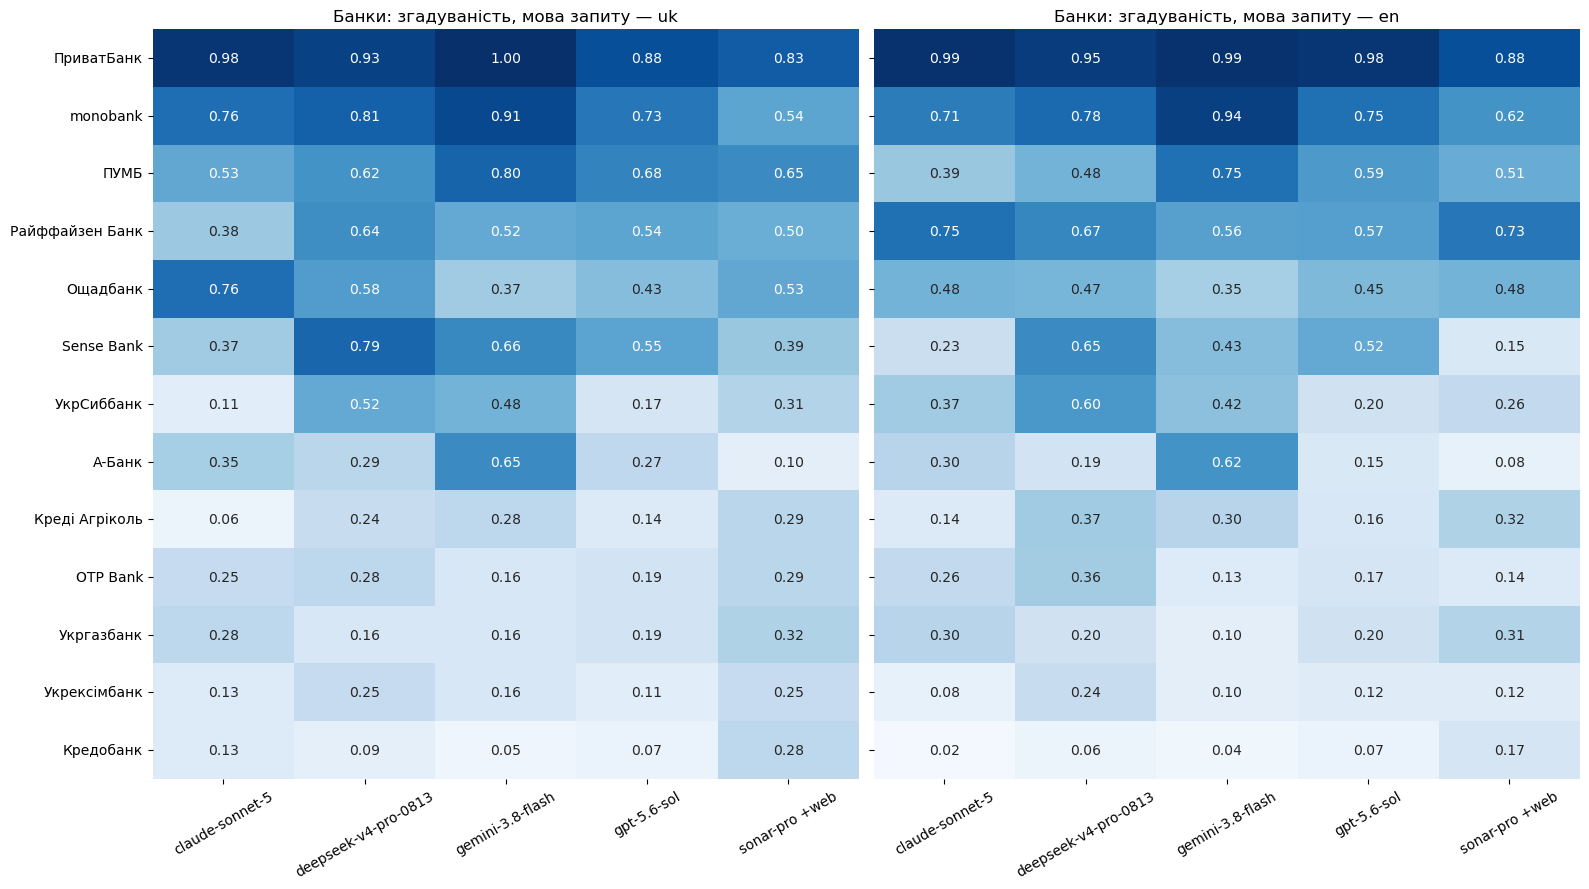


Згадуваність за мовою запиту (усі моделі разом):
lang                uk     en    gap
brand                               
ПриватБанк       0.924  0.958 -0.034
monobank         0.750  0.760 -0.010
ПУМБ             0.656  0.544  0.112
Sense Bank       0.552  0.396  0.156
Ощадбанк         0.534  0.446  0.088
Райффайзен Банк  0.516  0.656 -0.140
А-Банк           0.332  0.268  0.064
УкрСиббанк       0.318  0.370 -0.052
OTP Bank         0.234  0.212  0.022
Укргазбанк       0.222  0.222  0.000
Креді Агріколь   0.202  0.258 -0.056
Укрексімбанк     0.180  0.132  0.048
Кредобанк        0.124  0.072  0.052

Середня кількість відстежуваних брендів у відповіді:
lang
en    5.29
uk    5.54
dtype: float64

Частка перших місць (усі моделі й мови):
                 mention_rate  mean_rank  first_place_rate
brand                                                     
ПриватБанк              0.941       2.06             0.331
monobank                0.755       2.07             0.486
ПУМБ                 

In [7]:
report("bank")

===== E-commerce: відповідей 1000 із 1000 =====


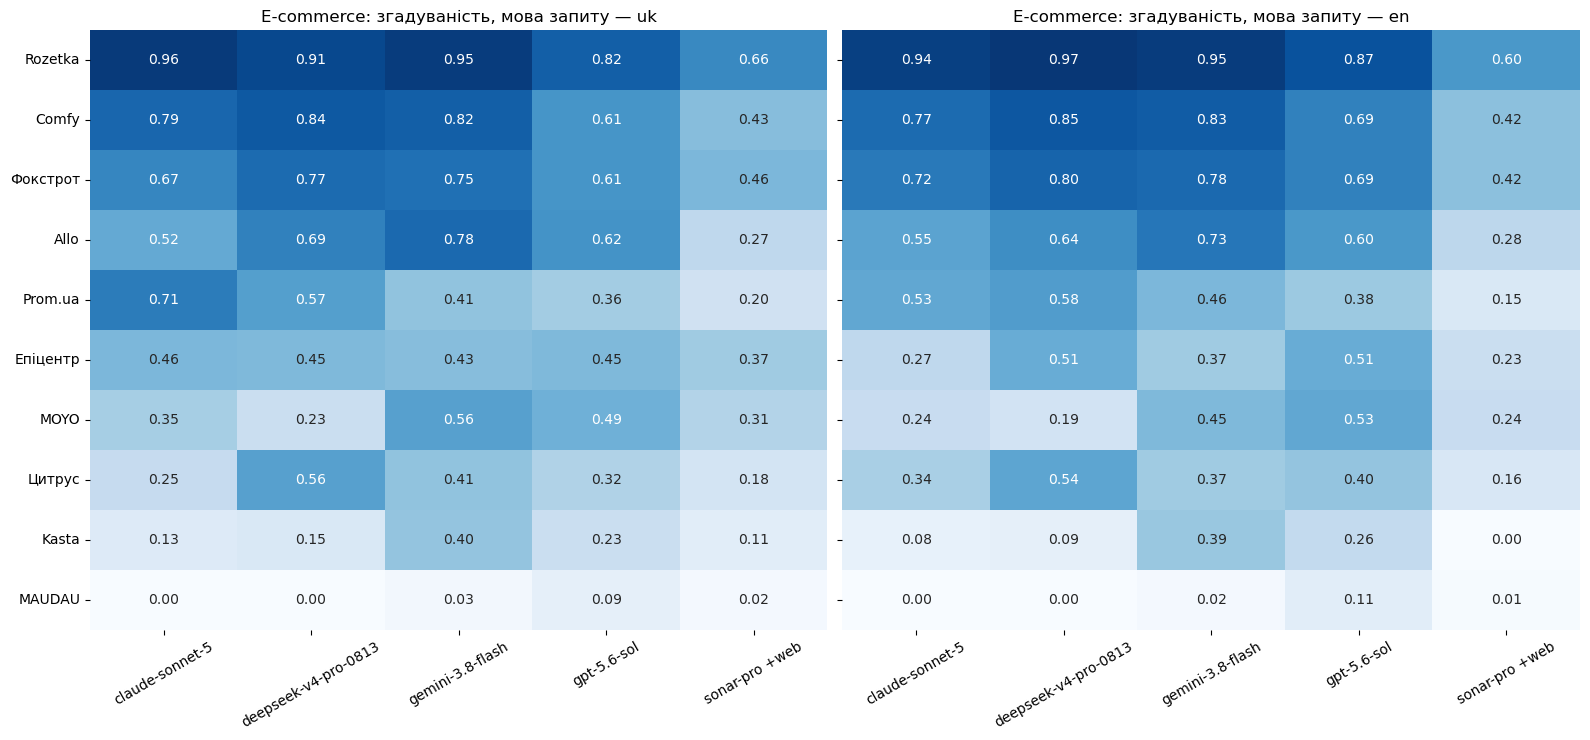


Згадуваність за мовою запиту (усі моделі разом):
lang         uk     en    gap
brand                        
Rozetka   0.860  0.866 -0.006
Comfy     0.698  0.712 -0.014
Фокстрот  0.652  0.682 -0.030
Allo      0.576  0.560  0.016
Prom.ua   0.450  0.420  0.030
Епіцентр  0.432  0.378  0.054
MOYO      0.388  0.330  0.058
Цитрус    0.344  0.362 -0.018
Kasta     0.204  0.164  0.040
MAUDAU    0.028  0.028  0.000

Середня кількість відстежуваних брендів у відповіді:
lang
en    4.50
uk    4.63
dtype: float64

Частка перших місць (усі моделі й мови):
          mention_rate  mean_rank  first_place_rate
brand                                              
Rozetka          0.863       1.51             0.674
Comfy            0.705       2.43             0.115
Фокстрот         0.667       3.27             0.021
Allo             0.568       4.25             0.010
Prom.ua          0.435       3.78             0.012
Епіцентр         0.405       4.18             0.020
MOYO             0.359       4.79   

In [8]:
report("ecom")

===== Аптеки: відповідей 1000 із 1000 =====


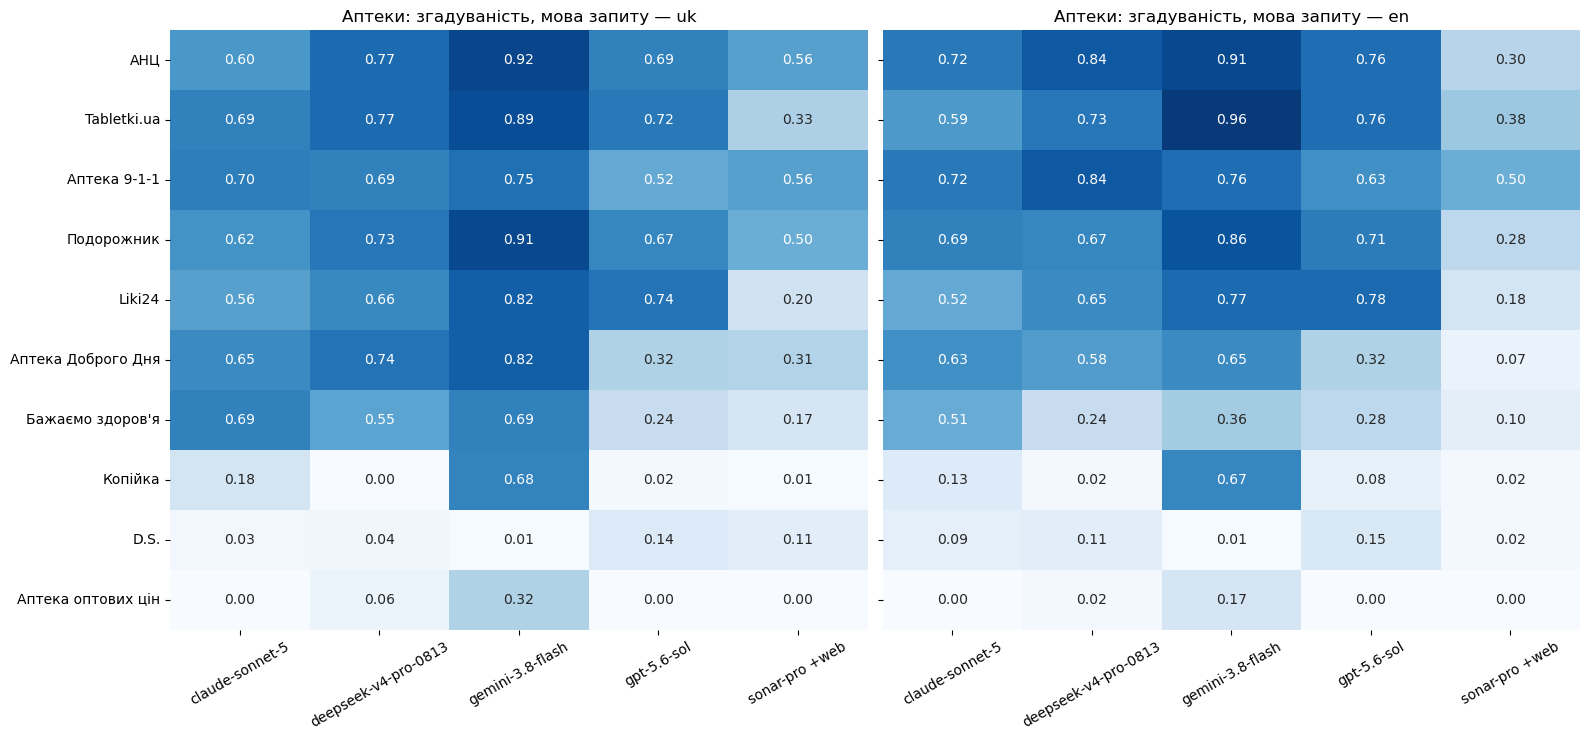


Згадуваність за мовою запиту (усі моделі разом):
lang                   uk     en    gap
brand                                  
АНЦ                 0.708  0.706  0.002
Подорожник          0.686  0.642  0.044
Tabletki.ua         0.680  0.684 -0.004
Аптека 9-1-1        0.644  0.690 -0.046
Liki24              0.596  0.580  0.016
Аптека Доброго Дня  0.568  0.450  0.118
Бажаємо здоров'я    0.468  0.298  0.170
Копійка             0.178  0.184 -0.006
Аптека оптових цін  0.076  0.038  0.038
D.S.                0.066  0.076 -0.010

Середня кількість відстежуваних брендів у відповіді:
lang
en    4.35
uk    4.67
dtype: float64

Частка перших місць (усі моделі й мови):
                    mention_rate  mean_rank  first_place_rate
brand                                                        
АНЦ                        0.707       2.57             0.188
Tabletki.ua                0.682       2.95             0.367
Аптека 9-1-1               0.667       3.27             0.124
Подорожник            

In [9]:
report("pharma")

===== Пошта і логістика: відповідей 500 із 500 =====


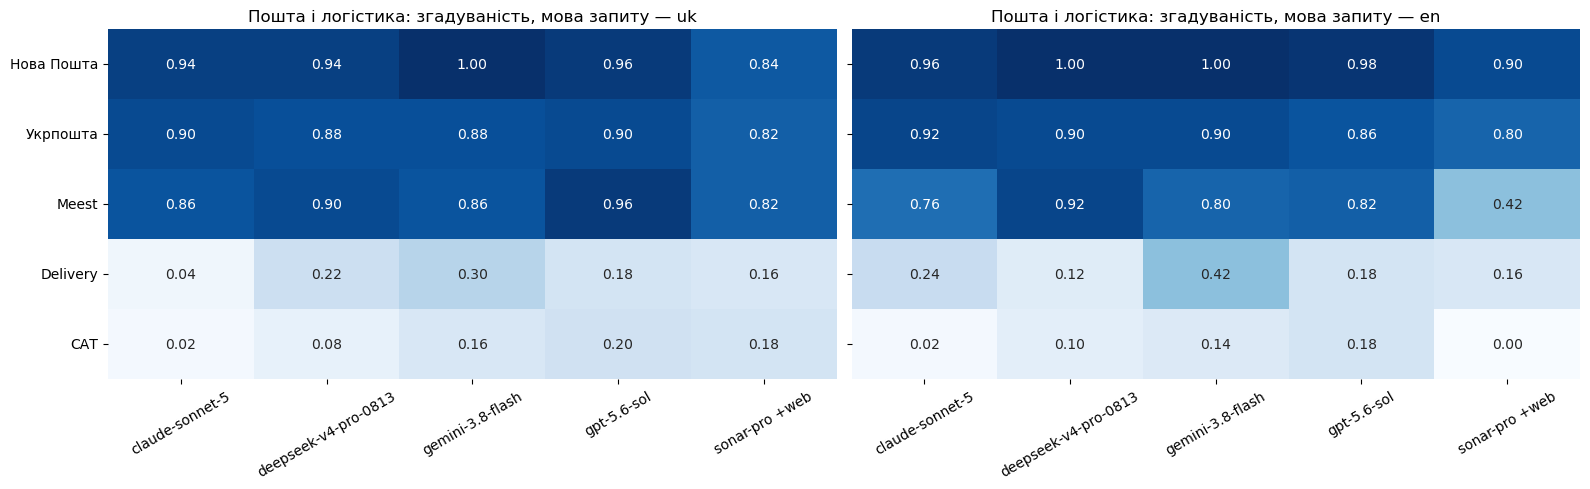


Згадуваність за мовою запиту (усі моделі разом):
lang           uk     en    gap
brand                          
Нова Пошта  0.936  0.968 -0.032
Meest       0.880  0.744  0.136
Укрпошта    0.876  0.876  0.000
Delivery    0.180  0.224 -0.044
САТ         0.128  0.088  0.040

Середня кількість відстежуваних брендів у відповіді:
lang
en    2.9
uk    3.0
dtype: float64

Частка перших місць (усі моделі й мови):
            mention_rate  mean_rank  first_place_rate
brand                                                
Нова Пошта         0.952       1.43             0.638
Укрпошта           0.876       1.86             0.248
Meest              0.812       2.72             0.048
Delivery           0.202       3.12             0.028
САТ                0.108       3.48             0.014

Згадуваність за інтентом:
intent      BEST  COMP  PRICE  TASK  TRUST
brand                                     
Delivery    0.46  0.03   0.18  0.30   0.04
Meest       0.92  0.81   0.94  0.60   0.79
Нова Пошта  1

In [10]:
report("post")

===== Доставка їжі і продуктів: відповідей 500 із 500 =====


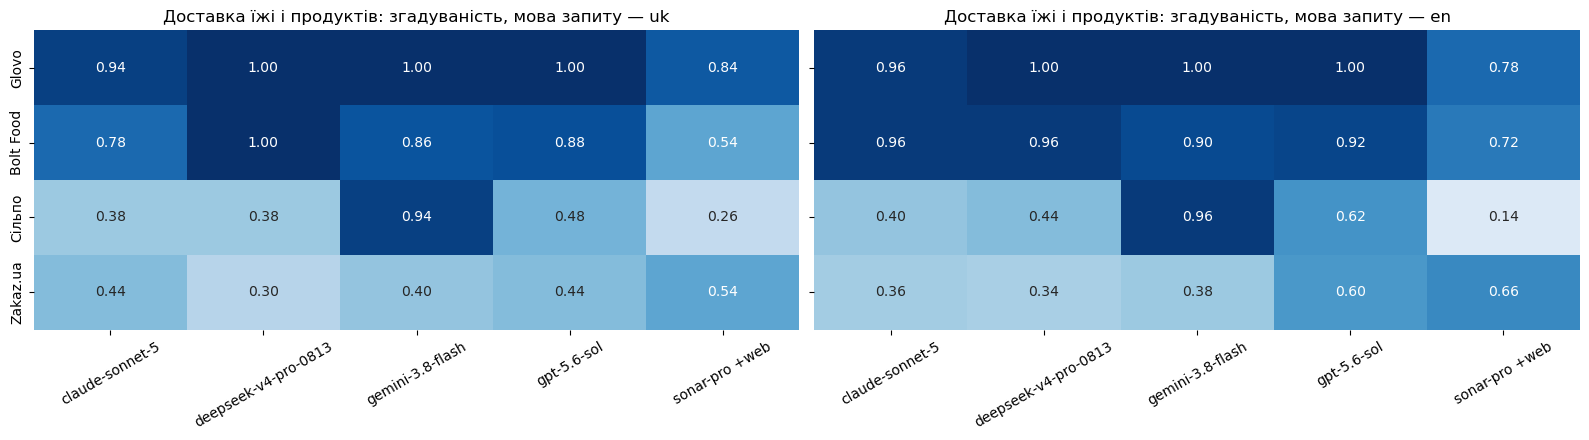


Згадуваність за мовою запиту (усі моделі разом):
lang          uk     en    gap
brand                         
Glovo      0.956  0.948  0.008
Bolt Food  0.812  0.892 -0.080
Сільпо     0.488  0.512 -0.024
Zakaz.ua   0.424  0.468 -0.044

Середня кількість відстежуваних брендів у відповіді:
lang
en    2.82
uk    2.68
dtype: float64

Частка перших місць (усі моделі й мови):
           mention_rate  mean_rank  first_place_rate
brand                                               
Glovo             0.952       1.61             0.538
Bolt Food         0.852       2.21             0.144
Сільпо            0.500       2.15             0.182
Zakaz.ua          0.446       2.43             0.112

Згадуваність за інтентом:
intent     BEST  COMP  PRICE  TASK  TRUST
brand                                    
Bolt Food  0.89  0.95   0.85  0.87   0.70
Glovo      1.00  0.96   0.93  0.95   0.92
Zakaz.ua   0.68  0.03   0.45  0.47   0.60
Сільпо     0.66  0.20   0.49  0.62   0.53

Стабільність між повторами (

In [11]:
report("food")

## 5. Зведення по всіх галузях

Заготовка для таблиць статті: індекс видимості бренду як середня згадуваність по моделях і мовах, плюс мовний розрив.

In [12]:
summary_rows = []
for industry in INDUSTRIES:
    spec, resp, ment, sent, _ = industry_frames(industry)
    if resp.empty or ment.empty:
        continue
    per_cell = audit.visibility_table(resp.assign(cell=resp["model_label"] + "|" + resp["lang"]),
                                      ment.assign(cell=ment["model_label"] + "|" + ment["lang"]), by="cell")
    cells = resp["model_label"].nunique() * resp["lang"].nunique()
    for brand in spec["brands"]:
        rows = per_cell[per_cell["brand"] == brand]
        by_lang = audit.visibility_table(resp, ment[ment["brand"] == brand], by="lang").set_index("lang")["mention_rate"] if not rows.empty else {}
        tracked = sent[(sent["brand"] == brand) & sent["tracked"]] if not sent.empty else sent
        summary_rows.append({
            "industry": spec["title"], "brand": brand,
            "visibility_index": round(rows["mention_rate"].sum() / cells, 3),
            "min_across_models": rows["mention_rate"].min() if len(rows) == cells else 0.0,
            "max_across_models": rows["mention_rate"].max() if not rows.empty else 0.0,
            "uk": by_lang.get("uk", 0.0), "en": by_lang.get("en", 0.0),
            "mean_sentiment": round(tracked["sentiment"].mean(), 2) if len(tracked) else None,
        })

summary = pd.DataFrame(summary_rows).sort_values(["industry", "visibility_index"], ascending=[True, False])
summary.to_csv("data/visibility_summary.csv", index=False)
summary

,industry,brand,visibility_index,min_across_models,max_across_models,uk,en,mean_sentiment
13,E-commerce,Rozetka,0.863,0.60,0.97,0.860,0.866,0.86
16,E-commerce,Comfy,0.705,0.42,0.85,0.698,0.712,0.87
17,E-commerce,Фокстрот,0.667,0.42,0.80,0.652,0.682,0.85
18,E-commerce,Allo,0.568,0.27,0.78,0.576,0.560,0.85
14,E-commerce,Prom.ua,0.435,0.15,0.71,0.450,0.420,0.56
15,E-commerce,Епіцентр,0.405,0.23,0.51,0.432,0.378,0.86
19,E-commerce,MOYO,0.359,0.19,0.56,0.388,0.330,0.87
22,E-commerce,Цитрус,0.353,0.16,0.56,0.344,0.362,0.87
20,E-commerce,Kasta,0.184,0.00,0.40,0.204,0.164,0.86
21,E-commerce,MAUDAU,0.028,0.00,0.11,0.028,0.028,0.93
